In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
    roc_curve,
    precision_recall_curve
)
from sklearn.linear_model import LogisticRegression
import joblib
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100

print("All imports done")

All imports done


In [2]:
# Data
X_train = joblib.load('../data/X_train.pkl')
X_test  = joblib.load('../data/X_test.pkl')
y_train = joblib.load('../data/y_train.pkl')
y_test  = joblib.load('../data/y_test.pkl')

# Models
lr          = joblib.load('../models/baseline_lr.pkl')
final_xgb   = joblib.load('../models/final_xgb.pkl')
final_lgbm  = joblib.load('../models/final_lgbm.pkl')
best_model  = joblib.load('../models/best_model.pkl')
best_thresh = joblib.load('../models/best_threshold.pkl')

# Probabilities
y_prob_lr         = lr.predict_proba(X_test)[:, 1]
y_prob_final_xgb  = joblib.load('../data/y_prob_final_xgb.pkl')
y_prob_final_lgbm = joblib.load('../data/y_prob_final_lgbm.pkl')
y_prob_best       = joblib.load('../data/y_prob_best.pkl')
y_pred_best       = joblib.load('../data/y_pred_best.pkl')

# Saved results
baseline_results = joblib.load('../models/baseline_results.pkl')
final_results    = joblib.load('../models/final_results.pkl')

print("=== ALL LOADED ===")
print(f"Test samples  : {len(y_test):,}")
print(f"Actual frauds : {y_test.sum():,}")
print(f"Best model    : {final_results['model']}")
print(f"Best threshold: {best_thresh:.4f}")

=== ALL LOADED ===
Test samples  : 56,962
Actual frauds : 98
Best model    : XGBoost
Best threshold: 0.5706


In [3]:
# Blend all 3 models — weighted average of probabilities
ensemble_prob = (
    0.4 * y_prob_final_xgb  +
    0.4 * y_prob_final_lgbm +
    0.2 * y_prob_lr
)

roc_ensemble   = roc_auc_score(y_test, ensemble_prob)
prauc_ensemble = average_precision_score(y_test, ensemble_prob)

# Optimize ensemble threshold
precision_ens, recall_ens, thresholds_ens = precision_recall_curve(
    y_test, ensemble_prob
)
target_recall = 0.85
valid_idx = np.where(recall_ens[:-1] >= target_recall)[0]

if len(valid_idx) > 0:
    best_idx_ens   = valid_idx[np.argmax(precision_ens[:-1][valid_idx])]
    thresh_ensemble = thresholds_ens[best_idx_ens]
else:
    thresh_ensemble = 0.5

y_pred_ensemble = (ensemble_prob >= thresh_ensemble).astype(int)

print("=== ENSEMBLE RESULTS ===\n")
print(classification_report(y_test, y_pred_ensemble,
      target_names=['Legitimate', 'Fraud']))
print(f"ROC-AUC : {roc_ensemble:.4f}")
print(f"PR-AUC  : {prauc_ensemble:.4f}")

=== ENSEMBLE RESULTS ===

              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56864
       Fraud       0.85      0.87      0.86        98

    accuracy                           1.00     56962
   macro avg       0.92      0.93      0.93     56962
weighted avg       1.00      1.00      1.00     56962

ROC-AUC : 0.9739
PR-AUC  : 0.8734


In [4]:
# Collect all scores
lr_roc   = roc_auc_score(y_test, y_prob_lr)
lr_prauc = average_precision_score(y_test, y_prob_lr)

models_summary = {
    'Logistic Regression' : {'roc': lr_roc,
                              'prauc': lr_prauc},
    'XGBoost (tuned)'     : {'roc': final_results['xgb_roc'],
                              'prauc': final_results['xgb_prauc']},
    'LightGBM (tuned)'    : {'roc': final_results['lgbm_roc'],
                              'prauc': final_results['lgbm_prauc']},
    'Ensemble'            : {'roc': roc_ensemble,
                              'prauc': prauc_ensemble},
}

print("=" * 52)
print(f"{'Model':<25} {'ROC-AUC':>12} {'PR-AUC':>12}")
print("=" * 52)
for name, scores in models_summary.items():
    marker = " ←" if scores['prauc'] == max(
        s['prauc'] for s in models_summary.values()) else ""
    print(f"{name:<25} {scores['roc']:>12.4f} "
          f"{scores['prauc']:>12.4f}{marker}")
print("=" * 52)

# Pick final best
best_name  = max(models_summary, key=lambda k: models_summary[k]['prauc'])
best_roc   = models_summary[best_name]['roc']
best_prauc = models_summary[best_name]['prauc']

if best_name == 'Ensemble':
    final_prob  = ensemble_prob
    final_pred  = y_pred_ensemble
    final_thresh = thresh_ensemble
else:
    final_prob  = y_prob_best
    final_pred  = y_pred_best
    final_thresh = best_thresh

print(f"\nFinal model for deployment: {best_name}")

Model                          ROC-AUC       PR-AUC
Logistic Regression             0.9736       0.7316
XGBoost (tuned)                 0.9805       0.8722
LightGBM (tuned)                0.9748       0.8718
Ensemble                        0.9739       0.8734 ←

Final model for deployment: Ensemble


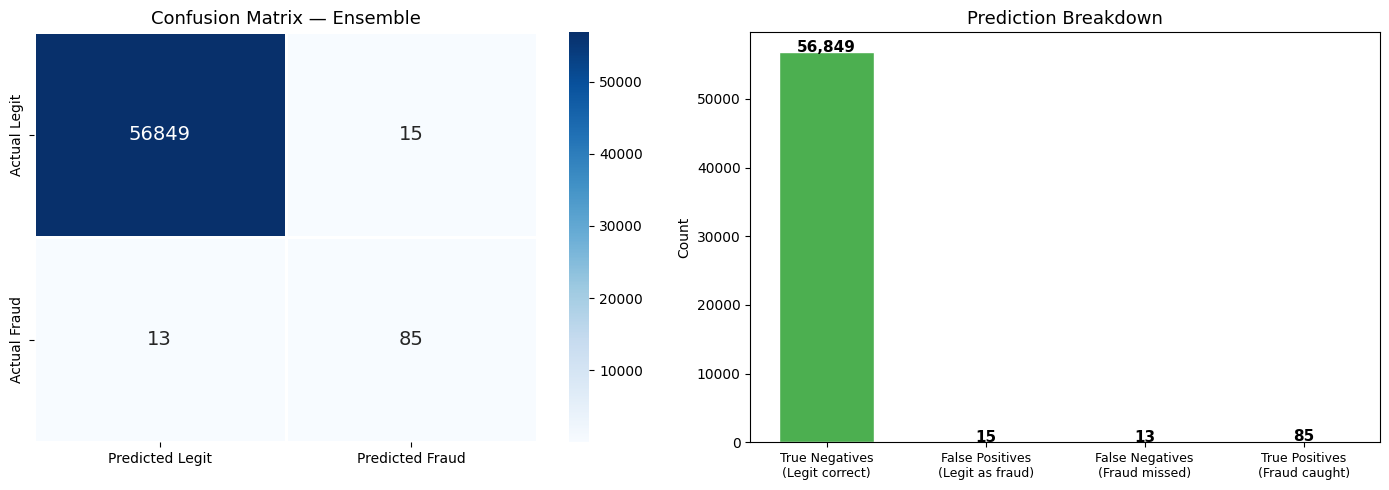


Fraud catch rate : 86.7%
False alarm rate : 0.026%
Frauds missed    : 13
Frauds caught    : 85


In [5]:
cm = confusion_matrix(y_test, final_pred)
tn, fp, fn, tp = cm.ravel()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Heatmap
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Legit', 'Predicted Fraud'],
            yticklabels=['Actual Legit', 'Actual Fraud'],
            ax=axes[0], linewidths=1, annot_kws={'size': 14})
axes[0].set_title(f'Confusion Matrix — {best_name}', fontsize=13)

# Business view
labels = ['True Negatives\n(Legit correct)',
          'False Positives\n(Legit as fraud)',
          'False Negatives\n(Fraud missed)',
          'True Positives\n(Fraud caught)']
values = [tn, fp, fn, tp]
colors = ['#4CAF50', '#FF9800', '#F44336', '#2196F3']

bars = axes[1].bar(range(4), values, color=colors, edgecolor='white', width=0.6)
axes[1].set_xticks(range(4))
axes[1].set_xticklabels(labels, fontsize=9)
axes[1].set_title('Prediction Breakdown', fontsize=13)
axes[1].set_ylabel('Count')
for bar, val in zip(bars, values):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 50,
                 f'{val:,}', ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('../data/16_final_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nFraud catch rate : {tp/(tp+fn)*100:.1f}%")
print(f"False alarm rate : {fp/(fp+tn)*100:.3f}%")
print(f"Frauds missed    : {fn}")
print(f"Frauds caught    : {tp}")

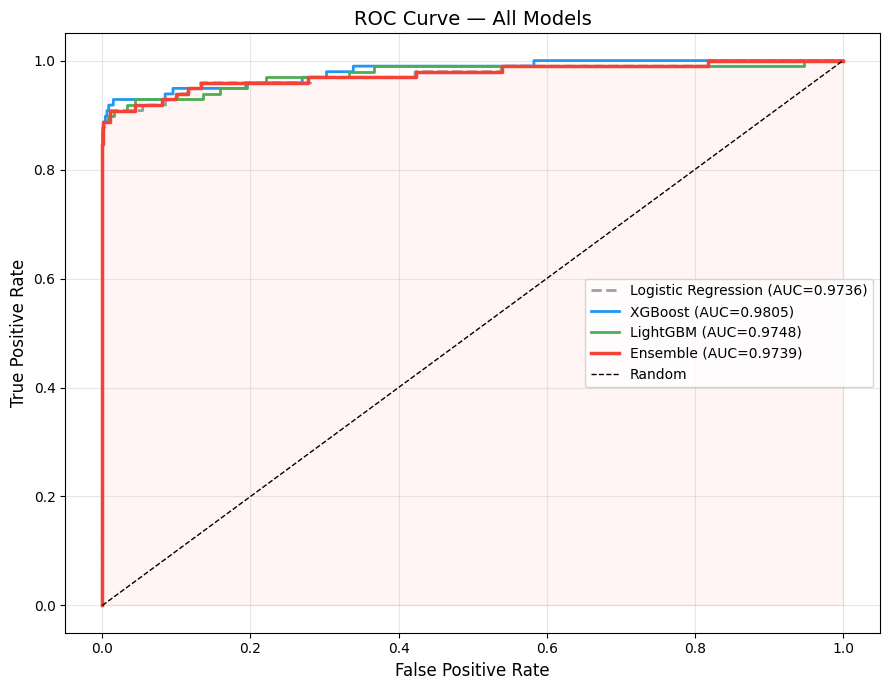

In [6]:
fpr_lr,   tpr_lr,   _ = roc_curve(y_test, y_prob_lr)
fpr_xgb,  tpr_xgb,  _ = roc_curve(y_test, y_prob_final_xgb)
fpr_lgbm, tpr_lgbm, _ = roc_curve(y_test, y_prob_final_lgbm)
fpr_ens,  tpr_ens,  _ = roc_curve(y_test, ensemble_prob)

plt.figure(figsize=(9, 7))
plt.plot(fpr_lr,   tpr_lr,
         label=f'Logistic Regression (AUC={lr_roc:.4f})',
         color='#9E9E9E', linewidth=2, linestyle='--')
plt.plot(fpr_xgb,  tpr_xgb,
         label=f'XGBoost (AUC={final_results["xgb_roc"]:.4f})',
         color='#2196F3', linewidth=2)
plt.plot(fpr_lgbm, tpr_lgbm,
         label=f'LightGBM (AUC={final_results["lgbm_roc"]:.4f})',
         color='#4CAF50', linewidth=2)
plt.plot(fpr_ens,  tpr_ens,
         label=f'Ensemble (AUC={roc_ensemble:.4f})',
         color='#F44336', linewidth=2.5)
plt.plot([0,1],[0,1],'k--', linewidth=1, label='Random')
plt.fill_between(fpr_ens, tpr_ens, alpha=0.05, color='#F44336')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve — All Models', fontsize=14)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../data/17_final_roc.png', dpi=150, bbox_inches='tight')
plt.show()

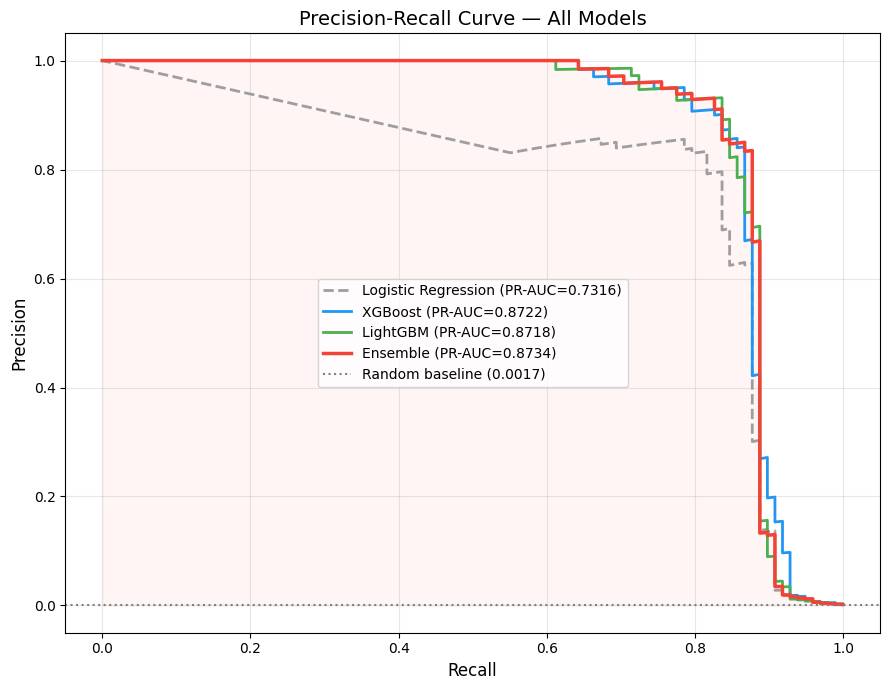

In [7]:
p_lr,   r_lr,   _ = precision_recall_curve(y_test, y_prob_lr)
p_xgb,  r_xgb,  _ = precision_recall_curve(y_test, y_prob_final_xgb)
p_lgbm, r_lgbm, _ = precision_recall_curve(y_test, y_prob_final_lgbm)
p_ens,  r_ens,  _ = precision_recall_curve(y_test, ensemble_prob)

plt.figure(figsize=(9, 7))
plt.plot(r_lr,   p_lr,
         label=f'Logistic Regression (PR-AUC={lr_prauc:.4f})',
         color='#9E9E9E', linewidth=2, linestyle='--')
plt.plot(r_xgb,  p_xgb,
         label=f'XGBoost (PR-AUC={final_results["xgb_prauc"]:.4f})',
         color='#2196F3', linewidth=2)
plt.plot(r_lgbm, p_lgbm,
         label=f'LightGBM (PR-AUC={final_results["lgbm_prauc"]:.4f})',
         color='#4CAF50', linewidth=2)
plt.plot(r_ens,  p_ens,
         label=f'Ensemble (PR-AUC={prauc_ensemble:.4f})',
         color='#F44336', linewidth=2.5)
plt.axhline(y=y_test.mean(), color='gray', linestyle=':',
            label=f'Random baseline ({y_test.mean():.4f})')
plt.fill_between(r_ens, p_ens, alpha=0.05, color='#F44336')
plt.xlabel('Recall', fontsize=12)
plt.ylabel('Precision', fontsize=12)
plt.title('Precision-Recall Curve — All Models', fontsize=14)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../data/18_final_pr_curve.png', dpi=150, bbox_inches='tight')
plt.show()

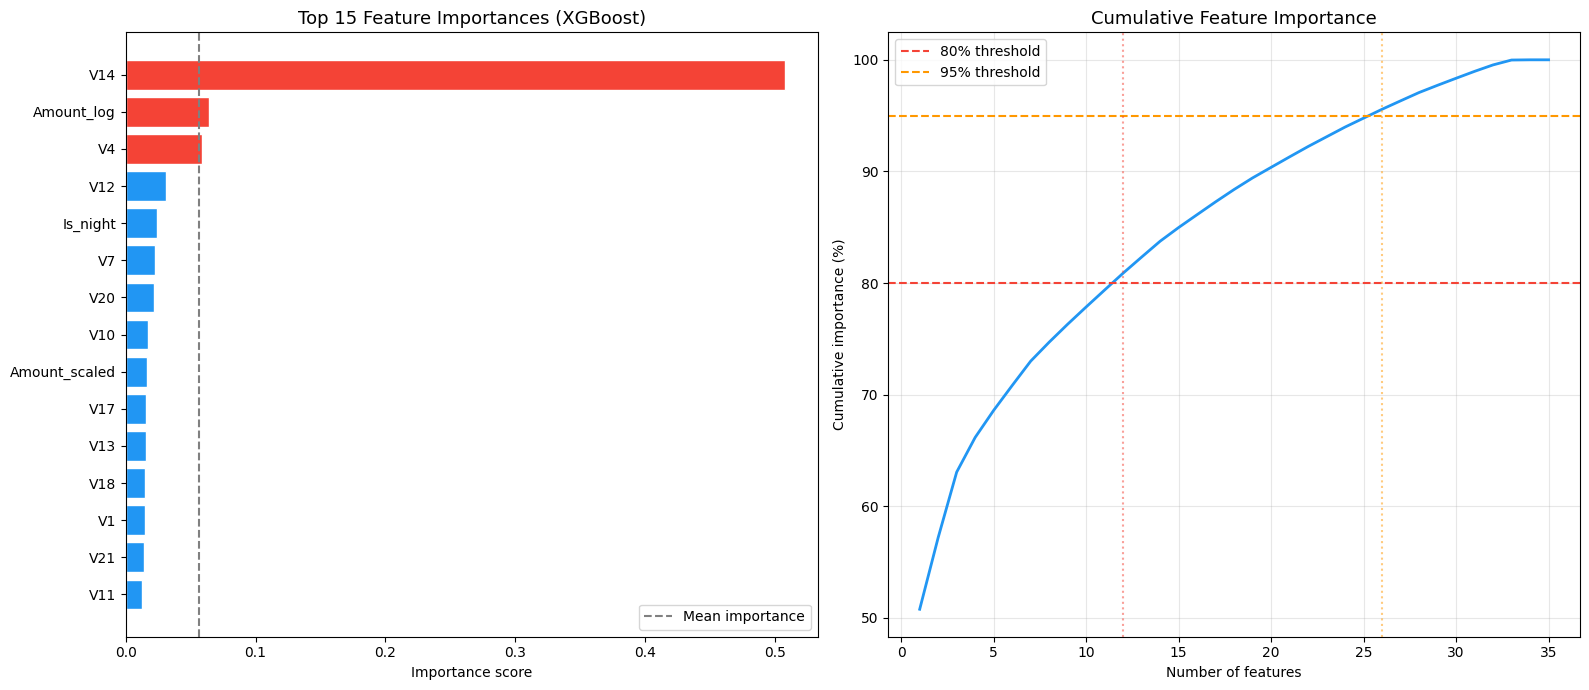

Top 3 most important features:
  V14: 0.5077
  Amount_log: 0.0643
  V4: 0.0586

12 features explain 80% of model decisions
26 features explain 95% of model decisions


In [8]:
# Use XGBoost importance (most interpretable)
feat_imp = pd.Series(
    final_xgb.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Top 15 bar chart
top15 = feat_imp.head(15)
colors = ['#F44336' if i < 3 else '#2196F3'
          for i in range(len(top15))]
axes[0].barh(top15.index, top15.values,
             color=colors, edgecolor='white')
axes[0].set_title('Top 15 Feature Importances (XGBoost)',
                  fontsize=13)
axes[0].set_xlabel('Importance score')
axes[0].invert_yaxis()
axes[0].axvline(x=top15.mean(), color='gray',
                linestyle='--', label='Mean importance')
axes[0].legend()

# Cumulative importance
cumsum = feat_imp.cumsum() / feat_imp.sum() * 100
axes[1].plot(range(1, len(cumsum)+1), cumsum.values,
             color='#2196F3', linewidth=2)
axes[1].axhline(y=80, color='#F44336', linestyle='--',
                label='80% threshold')
axes[1].axhline(y=95, color='#FF9800', linestyle='--',
                label='95% threshold')
n_80 = (cumsum <= 80).sum() + 1
n_95 = (cumsum <= 95).sum() + 1
axes[1].axvline(x=n_80, color='#F44336', linestyle=':', alpha=0.5)
axes[1].axvline(x=n_95, color='#FF9800', linestyle=':', alpha=0.5)
axes[1].set_title('Cumulative Feature Importance', fontsize=13)
axes[1].set_xlabel('Number of features')
axes[1].set_ylabel('Cumulative importance (%)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../data/19_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Top 3 most important features:")
for feat, score in feat_imp.head(3).items():
    print(f"  {feat}: {score:.4f}")
print(f"\n{n_80} features explain 80% of model decisions")
print(f"{n_95} features explain 95% of model decisions")

In [9]:
# Assume average fraudulent transaction = $122 (dataset mean)
avg_fraud_amount = 122

total_fraud       = y_test.sum()
fraud_caught      = tp
fraud_missed      = fn
false_alarms      = fp

money_saved       = fraud_caught * avg_fraud_amount
money_lost        = fraud_missed * avg_fraud_amount
catch_rate        = fraud_caught / total_fraud * 100
false_alarm_rate  = false_alarms / (tn + fp) * 100

print("=" * 55)
print("        BUSINESS IMPACT REPORT")
print("=" * 55)
print(f"""
DETECTION PERFORMANCE
  Total frauds in test set  : {total_fraud:,}
  Frauds caught             : {fraud_caught:,}  ({catch_rate:.1f}%)
  Frauds missed             : {fraud_missed:,}  ({100-catch_rate:.1f}%)

FINANCIAL IMPACT (estimated)
  Money saved (caught fraud): ${money_saved:,.0f}
  Money lost  (missed fraud): ${money_lost:,.0f}
  Net savings               : ${money_saved - money_lost:,.0f}

OPERATIONAL METRICS
  False alarms (legit flagged): {false_alarms:,}
  False alarm rate             : {false_alarm_rate:.3f}%
  → Only {false_alarm_rate:.3f}% of legit transactions
    are incorrectly flagged

MODEL SCORES
  ROC-AUC : {best_roc:.4f}
  PR-AUC  : {best_prauc:.4f}
""")
print("=" * 55)

        BUSINESS IMPACT REPORT

DETECTION PERFORMANCE
  Total frauds in test set  : 98
  Frauds caught             : 85  (86.7%)
  Frauds missed             : 13  (13.3%)

FINANCIAL IMPACT (estimated)
  Money saved (caught fraud): $10,370
  Money lost  (missed fraud): $1,586
  Net savings               : $8,784

OPERATIONAL METRICS
  False alarms (legit flagged): 15
  False alarm rate             : 0.026%
  → Only 0.026% of legit transactions
    are incorrectly flagged

MODEL SCORES
  ROC-AUC : 0.9739
  PR-AUC  : 0.8734



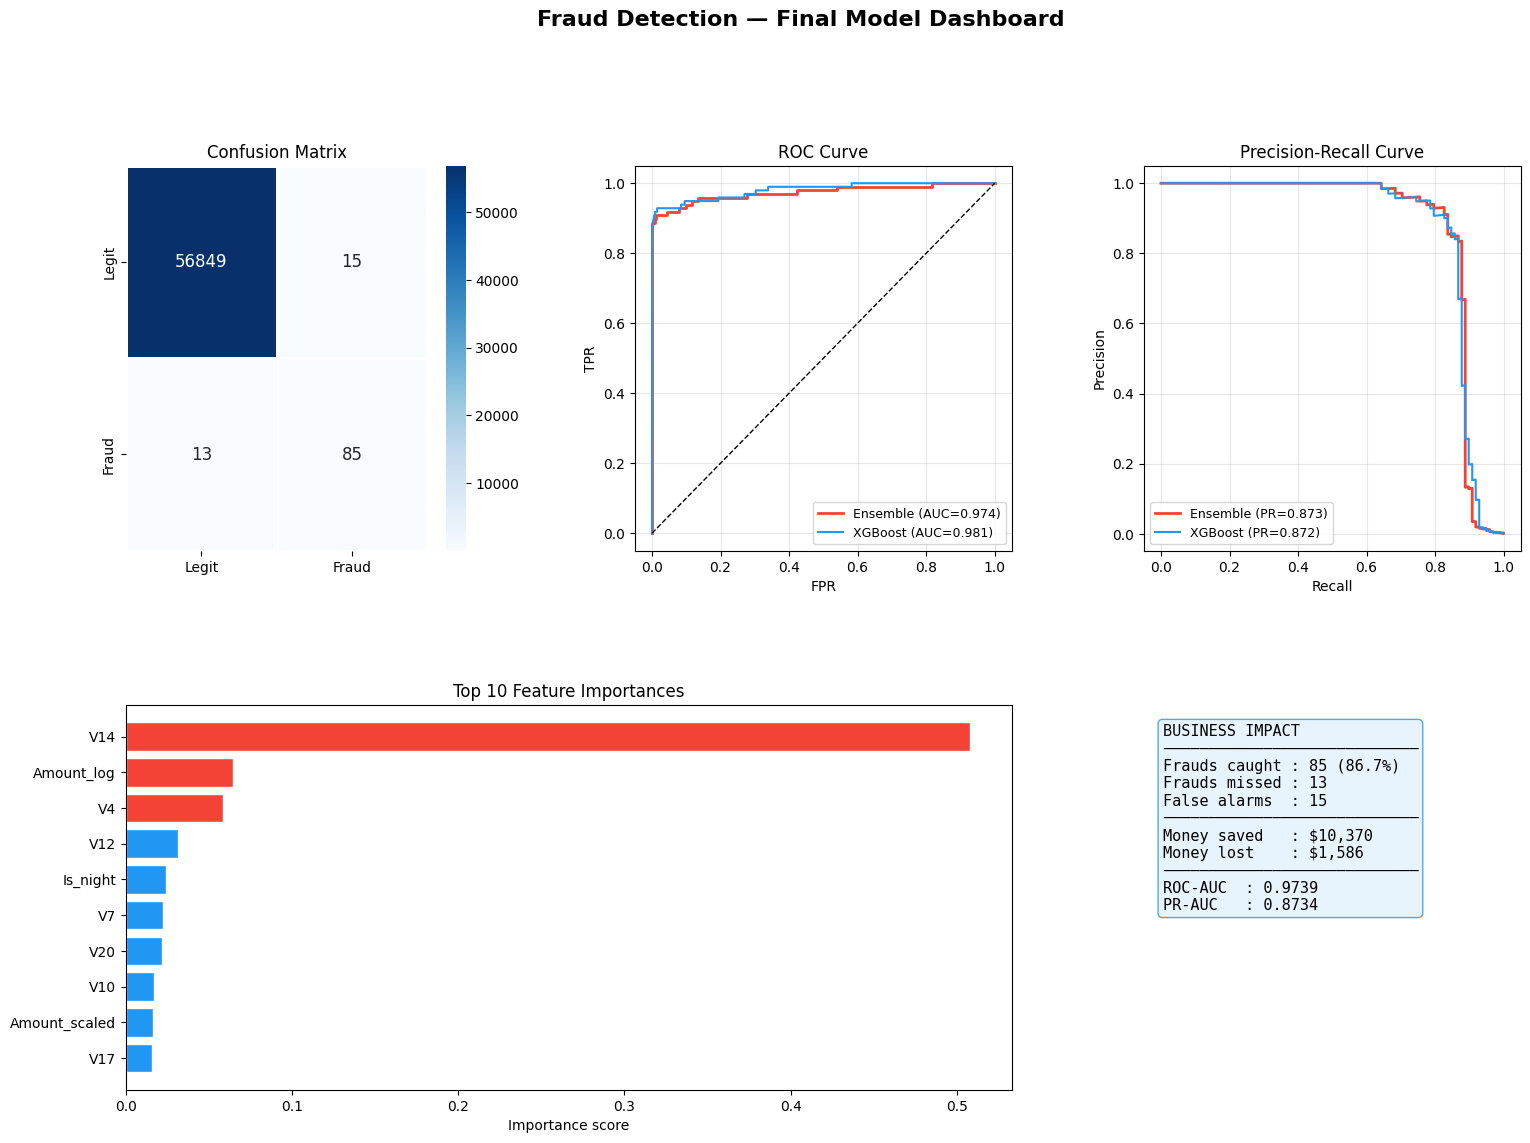

Master dashboard saved to data/20_final_dashboard.png
Use this image in your README and LinkedIn post


In [10]:
fig = plt.figure(figsize=(18, 12))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)

# 1. Confusion matrix
ax1 = fig.add_subplot(gs[0, 0])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Legit', 'Fraud'],
            yticklabels=['Legit', 'Fraud'],
            ax=ax1, linewidths=1, annot_kws={'size': 12})
ax1.set_title('Confusion Matrix', fontsize=12)

# 2. ROC curve
ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(fpr_ens, tpr_ens, color='#F44336', linewidth=2,
         label=f'Ensemble (AUC={roc_ensemble:.3f})')
ax2.plot(fpr_xgb, tpr_xgb, color='#2196F3', linewidth=1.5,
         label=f'XGBoost (AUC={final_results["xgb_roc"]:.3f})')
ax2.plot([0,1],[0,1],'k--', linewidth=1)
ax2.set_xlabel('FPR')
ax2.set_ylabel('TPR')
ax2.set_title('ROC Curve', fontsize=12)
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

# 3. PR curve
ax3 = fig.add_subplot(gs[0, 2])
ax3.plot(r_ens, p_ens, color='#F44336', linewidth=2,
         label=f'Ensemble (PR={prauc_ensemble:.3f})')
ax3.plot(r_xgb, p_xgb, color='#2196F3', linewidth=1.5,
         label=f'XGBoost (PR={final_results["xgb_prauc"]:.3f})')
ax3.set_xlabel('Recall')
ax3.set_ylabel('Precision')
ax3.set_title('Precision-Recall Curve', fontsize=12)
ax3.legend(fontsize=9)
ax3.grid(True, alpha=0.3)

# 4. Feature importance
ax4 = fig.add_subplot(gs[1, 0:2])
top10 = feat_imp.head(10)
colors_bar = ['#F44336' if i < 3 else '#2196F3'
              for i in range(len(top10))]
ax4.barh(top10.index, top10.values,
         color=colors_bar, edgecolor='white')
ax4.set_title('Top 10 Feature Importances', fontsize=12)
ax4.set_xlabel('Importance score')
ax4.invert_yaxis()

# 5. Business impact
ax5 = fig.add_subplot(gs[1, 2])
ax5.axis('off')
impact_text = (
    f"BUSINESS IMPACT\n"
    f"{'─'*28}\n"
    f"Frauds caught : {fraud_caught:,} ({catch_rate:.1f}%)\n"
    f"Frauds missed : {fraud_missed:,}\n"
    f"False alarms  : {false_alarms:,}\n"
    f"{'─'*28}\n"
    f"Money saved   : ${money_saved:,.0f}\n"
    f"Money lost    : ${money_lost:,.0f}\n"
    f"{'─'*28}\n"
    f"ROC-AUC  : {roc_ensemble:.4f}\n"
    f"PR-AUC   : {prauc_ensemble:.4f}"
)
ax5.text(0.05, 0.95, impact_text,
         transform=ax5.transAxes,
         fontsize=11, verticalalignment='top',
         fontfamily='monospace',
         bbox=dict(boxstyle='round', facecolor='#E3F2FD',
                   alpha=0.8, edgecolor='#2196F3'))

plt.suptitle('Fraud Detection — Final Model Dashboard',
             fontsize=16, fontweight='bold', y=1.01)
plt.savefig('../data/20_final_dashboard.png',
            dpi=150, bbox_inches='tight')
plt.show()

print("Master dashboard saved to data/20_final_dashboard.png")
print("Use this image in your README and LinkedIn post")

In [11]:
joblib.dump(ensemble_prob,   '../data/y_prob_ensemble.pkl')
joblib.dump(y_pred_ensemble, '../data/y_pred_ensemble.pkl')
joblib.dump(thresh_ensemble, '../models/ensemble_threshold.pkl')

# Save the deployment package
deploy_package = {
    'best_model_name' : best_name,
    'roc_auc'         : round(roc_ensemble, 4),
    'pr_auc'          : round(prauc_ensemble, 4),
    'threshold'       : round(thresh_ensemble, 4),
    'fraud_caught'    : int(fraud_caught),
    'fraud_missed'    : int(fraud_missed),
    'false_alarms'    : int(false_alarms),
    'catch_rate'      : round(catch_rate, 2),
    'money_saved'     : round(money_saved, 2),
    'money_lost'      : round(money_lost, 2),
    'feature_names'   : X_train.columns.tolist()
}

joblib.dump(deploy_package, '../models/deploy_package.pkl')

print("=== DEPLOYMENT PACKAGE SAVED ===")
print("models/deploy_package.pkl  ← used by Streamlit app")
print("models/ensemble_threshold.pkl")
print("data/y_prob_ensemble.pkl")

=== DEPLOYMENT PACKAGE SAVED ===
models/deploy_package.pkl  ← used by Streamlit app
models/ensemble_threshold.pkl
data/y_prob_ensemble.pkl
